# Cronbach's Alpha — Thử nghiệm bằng số thực

**Cronbach's Alpha** đo **độ nhất quán nội tại** của bộ câu hỏi.
Nếu các câu cùng đo một thứ, người trả lời cao câu này sẽ có xu hướng cao câu kia.

---

| Alpha | Đánh giá |
|:------|:---------|
| ≥ 0.9 | Xuất sắc |
| ≥ 0.8 | Tốt |
| ≥ 0.7 | Chấp nhận được |
| ≥ 0.6 | Đáng ngờ |
| < 0.5 hoặc âm | Không chấp nhận |

---

**Nội dung thực nghiệm:**
1. So sánh 4 kịch bản từ nhất quán hoàn toàn đến hoàn toàn ngẫu nhiên
2. Tăng dần số câu nhiễu — alpha thay đổi thế nào?
3. Tăng dần số người trả lời random — alpha thay đổi thế nào?
4. So sánh trực tiếp: câu nhiễu hay người random ảnh hưởng hơn?


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
N_PEOPLE = 10
N_Q = 12

def cronbach_alpha(df):
    k = df.shape[1]
    iv = df.var(axis=0, ddof=1).sum()
    tv = df.sum(axis=1).var(ddof=1)
    if tv == 0: return float('nan')
    return (k / (k - 1)) * (1 - iv / tv)

def verdict(a):
    if np.isnan(a):  return 'Không xác định'
    if a >= 0.9:     return 'Xuất sắc'
    if a >= 0.8:     return 'Tốt'
    if a >= 0.7:     return 'Chấp nhận được'
    if a >= 0.6:     return 'Đáng ngờ'
    if a >= 0.5:     return 'Kém'
    return 'Không chấp nhận'

def show(lbl, a):
    val = f'{a:.4f}' if not np.isnan(a) else '  nan '
    print(f'  {lbl}: Alpha = {val}  →  {verdict(a)}')

print('Setup xong!')


Setup xong!


---
## Kịch bản 1 — Nhất quán tuyệt đối

Người i chọn giá trị `i+1` cho **tất cả** câu.

```
Người 0  → [ 1,  1,  1, ...,  1]
Người 5  → [ 6,  6,  6, ...,  6]
Người 9  → [10, 10, 10, ..., 10]
```

**Kỳ vọng:** Tương quan hoàn hảo → **alpha = 1.0**


In [89]:
data_s1 = np.array([[i+1]*N_Q for i in range(N_PEOPLE)])
df_s1 = pd.DataFrame(data_s1, columns=[f'Q{i+1}' for i in range(N_Q)])
print(df_s1.to_string())
print()
alpha_s1 = cronbach_alpha(df_s1)
show('KB1', alpha_s1)


   Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  Q11  Q12
0   1   1   1   1   1   1   1   1   1    1    1    1
1   2   2   2   2   2   2   2   2   2    2    2    2
2   3   3   3   3   3   3   3   3   3    3    3    3
3   4   4   4   4   4   4   4   4   4    4    4    4
4   5   5   5   5   5   5   5   5   5    5    5    5
5   6   6   6   6   6   6   6   6   6    6    6    6
6   7   7   7   7   7   7   7   7   7    7    7    7
7   8   8   8   8   8   8   8   8   8    8    8    8
8   9   9   9   9   9   9   9   9   9    9    9    9
9  10  10  10  10  10  10  10  10  10   10   10   10

  KB1: Alpha = 1.0000  →  Xuất sắc


---
## Kịch bản 2 — Q12 lệch nhỏ (±1 so với giá trị gốc)

Q12 = giá trị gốc ± 1. Nhiễu rất nhỏ, vẫn bám sát pattern.

**Kỳ vọng:** Alpha **gần 1.0**, chỉ giảm nhẹ.


In [90]:
data_s2 = np.array([[i+1]*N_Q for i in range(N_PEOPLE)], dtype=float)
noise = np.random.choice([-1, 0, 1], size=N_PEOPLE)
data_s2[:, -1] = np.clip(data_s2[:, -1] + noise, 1, 10)
df_s2 = pd.DataFrame(data_s2, columns=[f'Q{i+1}' for i in range(N_Q)])
print(df_s2.to_string())
print(f'\nNoise Q12: {noise}')
print()
alpha_s2 = cronbach_alpha(df_s2)
show('KB2', alpha_s2)


     Q1    Q2    Q3    Q4    Q5    Q6    Q7    Q8    Q9   Q10   Q11   Q12
0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   2.0
1   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   1.0
2   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   4.0
3   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   5.0
4   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   4.0
5   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   5.0
6   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   8.0
7   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0
8   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0  10.0
9  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0

Noise Q12: [ 1 -1  1  1 -1 -1  1  0  1  1]

  KB2: Alpha = 0.9994  →  Xuất sắc


---
## Kịch bản 3 — Q12 hoàn toàn ngẫu nhiên

11 câu đầu giữ nguyên, Q12 random 1–10 (không liên quan gốc).

**Kỳ vọng:** Alpha **giảm rõ rệt** so với KB2.


In [91]:
data_s3 = np.array([[i+1]*N_Q for i in range(N_PEOPLE)], dtype=float)
data_s3[:, -1] = np.random.randint(1, 11, size=N_PEOPLE)
df_s3 = pd.DataFrame(data_s3, columns=[f'Q{i+1}' for i in range(N_Q)])
print(df_s3.to_string())
print()
alpha_s3 = cronbach_alpha(df_s3)
show('KB3', alpha_s3)


     Q1    Q2    Q3    Q4    Q5    Q6    Q7    Q8    Q9   Q10   Q11  Q12
0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0  8.0
1   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0  5.0
2   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0  4.0
3   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0   4.0  8.0
4   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0   5.0  8.0
5   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0   6.0  3.0
6   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0   7.0  6.0
7   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0   8.0  5.0
8   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0  2.0
9  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  8.0

  KB3: Alpha = 0.9840  →  Xuất sắc


---
## Kịch bản 4 — Tất cả ngẫu nhiên

Mọi ô chọn random 1–10, không có pattern nào.

**Kỳ vọng:** Alpha **≈ 0 hoặc âm**.

> **Alpha âm** = các câu tình cờ ngược chiều nhau.  
> Trong thực tế thường do câu bị **reverse-coded** mà chưa xử lý.


In [92]:
data_s4 = np.random.randint(1, 11, size=(N_PEOPLE, N_Q))
df_s4 = pd.DataFrame(data_s4, columns=[f'Q{i+1}' for i in range(N_Q)])
print(df_s4.to_string())
print()
alpha_s4 = cronbach_alpha(df_s4)
show('KB4', alpha_s4)


   Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  Q11  Q12
0   6   2   5   1  10   6   9   1  10    3    7    4
1   9   3   5   3   7   5   9   7   2    4    9    2
2  10   9  10   5   2   4   7   8   3    1    4    2
3   8   4   2   6   6  10   4   6   2   10    2   10
4   4   8   7   9   8   5   2   5   8   10    9    9
5   1   9   7   9   8   1   8   8   3    1    8    3
6   3   1   5  10   7  10   9   7   9    8    2    1
7   7   7   8   5   3   8   6   3   1    3    5    3
8   1   5  10   7   7   9  10  10   3    7    1    4
9   4   5   7   7   4   7   3   6   2   10    9    5

  KB4: Alpha = -1.3493  →  Không chấp nhận


---
## Tổng kết 4 kịch bản


In [93]:
scenarios = [
    ('KB1: Nhất quán tuyệt đối',    alpha_s1),
    ('KB2: Q12 lệch ±1',            alpha_s2),
    ('KB3: Q12 random',             alpha_s3),
    ('KB4: Tất cả random',          alpha_s4),
]
print(f"{'Kịch bản':<35} {'Alpha':>8}  Đánh giá")
print('-' * 65)
for lbl, a in scenarios:
    val = f'{a:.4f}' if not np.isnan(a) else '   nan'
    print(f'{lbl:<35} {val:>8}  {verdict(a)}')


Kịch bản                               Alpha  Đánh giá
-----------------------------------------------------------------
KB1: Nhất quán tuyệt đối              1.0000  Xuất sắc
KB2: Q12 lệch ±1                      0.9994  Xuất sắc
KB3: Q12 random                       0.9840  Xuất sắc
KB4: Tất cả random                   -1.3493  Không chấp nhận


---
## Kết luận

| Kịch bản | Alpha kỳ vọng | Ý nghĩa |
|:---------|:-------------|:--------|
| Nhất quán tuyệt đối | **1.0** | Tương quan hoàn hảo |
| Q12 lệch ±1 | **rất gần 1.0** | Nhiễu nhỏ ảnh hưởng không đáng kể |
| Q12 random | **giảm rõ rệt** | 1 câu lỗi kéo alpha xuống |
| Tất cả random | **≈ 0 hoặc âm** | Bộ câu hỏi không đo được gì |


---
## Thực nghiệm 2 — Tăng dần số câu nhiễu

Giữ nguyên 12 câu, 10 người. Tăng số câu bị nhiễu random từ **0 → 12**, mỗi mức chạy **2000 lần**.

> **Câu nhiễu** = câu mà người trả lời chọn hoàn toàn ngẫu nhiên, không phản ánh xu hướng thực của họ.


In [94]:
N_TRIALS = 2000
noisy_results = []

for n_noisy in range(N_Q + 1):
    alphas = []
    for _ in range(N_TRIALS):
        d = np.array([[i+1]*N_Q for i in range(N_PEOPLE)], dtype=float)
        noisy_cols = np.random.choice(N_Q, size=n_noisy, replace=False)
        d[:, noisy_cols] = np.random.randint(1, 11, size=(N_PEOPLE, n_noisy))
        alphas.append(cronbach_alpha(pd.DataFrame(d)))
    noisy_results.append((n_noisy, np.nanmean(alphas), np.nanstd(alphas)))
    print(f'  {n_noisy:2d}/{N_Q} câu nhiễu → alpha = {np.nanmean(alphas):.4f} ± {np.nanstd(alphas):.4f}')


   0/12 câu nhiễu → alpha = 1.0000 ± 0.0000
   1/12 câu nhiễu → alpha = 0.9842 ± 0.0066
   2/12 câu nhiễu → alpha = 0.9635 ± 0.0122
   3/12 câu nhiễu → alpha = 0.9361 ± 0.0192
   4/12 câu nhiễu → alpha = 0.8987 ± 0.0310
   5/12 câu nhiễu → alpha = 0.8466 ± 0.0504
   6/12 câu nhiễu → alpha = 0.7730 ± 0.0858
   7/12 câu nhiễu → alpha = 0.6564 ± 0.1453
   8/12 câu nhiễu → alpha = 0.4896 ± 0.2625
   9/12 câu nhiễu → alpha = 0.2406 ± 0.4326
  10/12 câu nhiễu → alpha = -0.0824 ± 0.7351
  11/12 câu nhiễu → alpha = -0.2947 ± 0.8030
  12/12 câu nhiễu → alpha = -0.3059 ± 0.8830


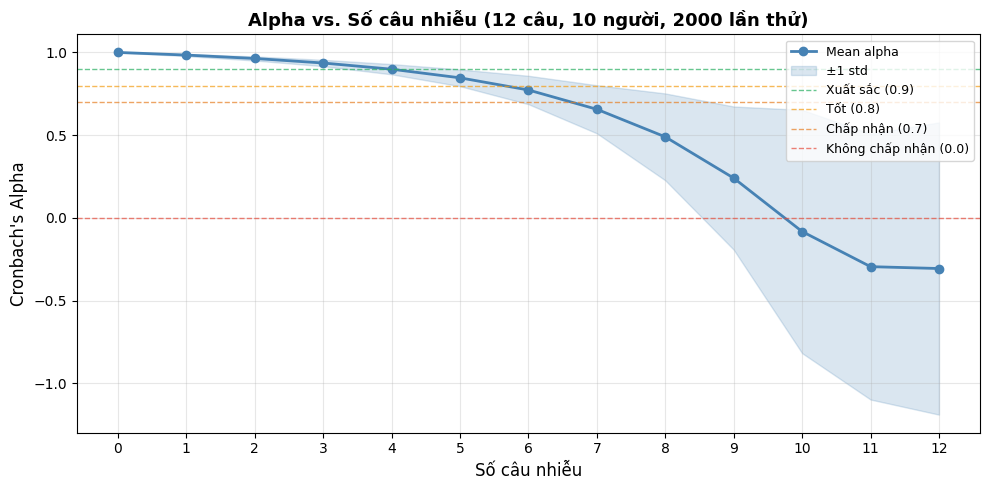


 Câu nhiễu   Mean alpha      Std  Đánh giá
-------------------------------------------------------
         0       1.0000   0.0000  Xuất sắc              ████████████
         1       0.9842   0.0066  Xuất sắc              ███████████░
         2       0.9635   0.0122  Xuất sắc              ██████████░░
         3       0.9361   0.0192  Xuất sắc              █████████░░░
         4       0.8987   0.0310  Tốt                   ████████░░░░
         5       0.8466   0.0504  Tốt                   ███████░░░░░
         6       0.7730   0.0858  Chấp nhận được        ██████░░░░░░
         7       0.6564   0.1453  Đáng ngờ              █████░░░░░░░
         8       0.4896   0.2625  Không chấp nhận       ████░░░░░░░░
         9       0.2406   0.4326  Không chấp nhận       ███░░░░░░░░░
        10      -0.0824   0.7351  Không chấp nhận       ██░░░░░░░░░░
        11      -0.2947   0.8030  Không chấp nhận       █░░░░░░░░░░░
        12      -0.3059   0.8830  Không chấp nhận       ░░░░░░░░░░░░


In [95]:
ns    = [r[0] for r in noisy_results]
means = [r[1] for r in noisy_results]
stds  = [r[2] for r in noisy_results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ns, means, 'o-', color='steelblue', lw=2, ms=6, label='Mean alpha')
ax.fill_between(ns, [m-s for m,s in zip(means,stds)], [m+s for m,s in zip(means,stds)],
                alpha=0.2, color='steelblue', label='±1 std')

for val, lbl, color in [(0.9,'Xuất sắc','#27ae60'),(0.8,'Tốt','#f39c12'),
                         (0.7,'Chấp nhận','#e67e22'),(0.0,'Không chấp nhận','#e74c3c')]:
    ax.axhline(val, color=color, lw=1, ls='--', alpha=0.7, label=f'{lbl} ({val})')

ax.set_xlabel('Số câu nhiễu', fontsize=12)
ax.set_ylabel("Cronbach's Alpha", fontsize=12)
ax.set_title(f'Alpha vs. Số câu nhiễu ({N_Q} câu, {N_PEOPLE} người, {N_TRIALS} lần thử)', fontsize=13, fontweight='bold')
ax.set_xticks(ns)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Câu nhiễu':>10} {'Mean alpha':>12} {'Std':>8}  Đánh giá")
print('-' * 55)
for n_noisy, mean_a, std_a in noisy_results:
    bar = '█' * (N_Q - n_noisy) + '░' * n_noisy
    print(f'{n_noisy:>10} {mean_a:>12.4f} {std_a:>8.4f}  {verdict(mean_a):20s}  {bar}')


---
## Thực nghiệm 3 — Tăng dần số người trả lời random

Giữ nguyên 12 câu, 10 người.
- **Người hợp lý:** người i chọn `i+1` cho tất cả câu (nhất quán)
- **Người random:** chọn hoàn toàn ngẫu nhiên 1–10 cho mọi câu

Tăng số người random từ **0 → 10**, mỗi mức chạy **2000 lần**.

> **Người random** trong thực tế = người không đọc câu hỏi, bấm đại cho xong.


In [107]:
N_TRIALS_P = 2000
people_results = []

for n_random_people in range(N_PEOPLE + 1):
    alphas = []
    for _ in range(N_TRIALS_P):
        # n_good người đầu: nhất quán
        n_good_people = N_PEOPLE - n_random_people
        rows = []
        for i in range(n_good_people):
            rows.append([i + 1] * N_Q)
        for _ in range(n_random_people):
            rows.append(list(np.random.randint(1, 11, size=N_Q)))
        d = pd.DataFrame(rows, columns=[f'Q{i+1}' for i in range(N_Q)])
        alphas.append(cronbach_alpha(d))
    people_results.append((n_random_people, np.nanmean(alphas), np.nanstd(alphas)))
    print(f'  {n_random_people:2d}/{N_PEOPLE} người random → alpha = {np.nanmean(alphas):.4f} ± {np.nanstd(alphas):.4f}')


   0/10 người random → alpha = 1.0000 ± 0.0000
   1/10 người random → alpha = 0.9898 ± 0.0029
   2/10 người random → alpha = 0.9724 ± 0.0059
   3/10 người random → alpha = 0.9460 ± 0.0108
   4/10 người random → alpha = 0.9139 ± 0.0182
   5/10 người random → alpha = 0.8891 ± 0.0252
   6/10 người random → alpha = 0.8725 ± 0.0290
   7/10 người random → alpha = 0.8604 ± 0.0295
   8/10 người random → alpha = 0.8378 ± 0.0316
   9/10 người random → alpha = 0.7610 ± 0.0455
  10/10 người random → alpha = -0.2848 ± 0.8959
  10/10 người random → alpha = -0.2848 ± 0.8959


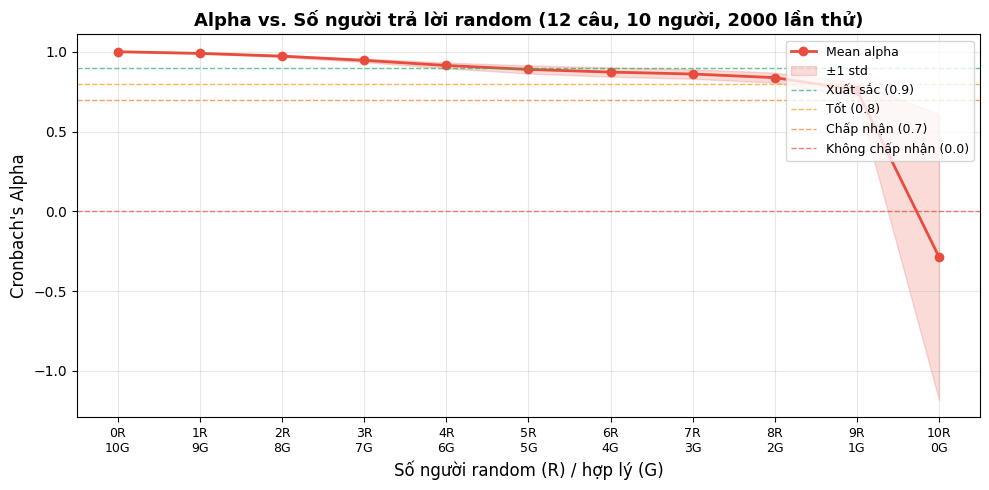


 Người random  Người hợp lý   Mean alpha      Std  Đánh giá
-----------------------------------------------------------------
            0            10       1.0000   0.0000  Xuất sắc              ●●●●●●●●●●
            1             9       0.9898   0.0029  Xuất sắc              ●●●●●●●●●○
            2             8       0.9724   0.0059  Xuất sắc              ●●●●●●●●○○
            3             7       0.9460   0.0108  Xuất sắc              ●●●●●●●○○○
            4             6       0.9139   0.0182  Xuất sắc              ●●●●●●○○○○
            5             5       0.8891   0.0252  Tốt                   ●●●●●○○○○○
            6             4       0.8725   0.0290  Tốt                   ●●●●○○○○○○
            7             3       0.8604   0.0295  Tốt                   ●●●○○○○○○○
            8             2       0.8378   0.0316  Tốt                   ●●○○○○○○○○
            9             1       0.7610   0.0455  Chấp nhận được        ●○○○○○○○○○
           10             0      

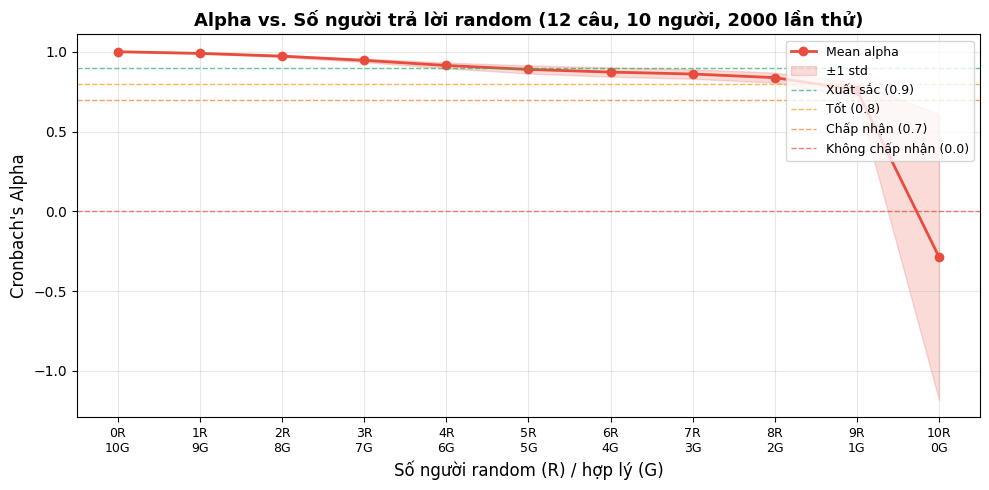


 Người random  Người hợp lý   Mean alpha      Std  Đánh giá
-----------------------------------------------------------------
            0            10       1.0000   0.0000  Xuất sắc              ●●●●●●●●●●
            1             9       0.9898   0.0029  Xuất sắc              ●●●●●●●●●○
            2             8       0.9724   0.0059  Xuất sắc              ●●●●●●●●○○
            3             7       0.9460   0.0108  Xuất sắc              ●●●●●●●○○○
            4             6       0.9139   0.0182  Xuất sắc              ●●●●●●○○○○
            5             5       0.8891   0.0252  Tốt                   ●●●●●○○○○○
            6             4       0.8725   0.0290  Tốt                   ●●●●○○○○○○
            7             3       0.8604   0.0295  Tốt                   ●●●○○○○○○○
            8             2       0.8378   0.0316  Tốt                   ●●○○○○○○○○
            9             1       0.7610   0.0455  Chấp nhận được        ●○○○○○○○○○
           10             0      

In [108]:
ns_p    = [r[0] for r in people_results]
means_p = [r[1] for r in people_results]
stds_p  = [r[2] for r in people_results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ns_p, means_p, 'o-', color='#e74c3c', lw=2, ms=6, label='Mean alpha')
ax.fill_between(ns_p,
                [m - s for m, s in zip(means_p, stds_p)],
                [m + s for m, s in zip(means_p, stds_p)],
                alpha=0.2, color='#e74c3c', label='±1 std')

for val, lbl, color in [(0.9,'Xuất sắc','#27ae60'),(0.8,'Tốt','#f39c12'),
                         (0.7,'Chấp nhận','#e67e22'),(0.0,'Không chấp nhận','#e74c3c')]:
    ax.axhline(val, color=color, lw=1, ls='--', alpha=0.7, label=f'{lbl} ({val})')

# Nhãn trục x rõ hơn
ax.set_xticks(ns_p)
ax.set_xticklabels([f'{n}R\n{N_PEOPLE-n}G' for n in ns_p], fontsize=9)
ax.set_xlabel('Số người random (R) / hợp lý (G)', fontsize=12)
ax.set_ylabel("Cronbach's Alpha", fontsize=12)
ax.set_title(f'Alpha vs. Số người trả lời random ({N_Q} câu, {N_PEOPLE} người, {N_TRIALS_P} lần thử)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Người random':>13} {'Người hợp lý':>13} {'Mean alpha':>12} {'Std':>8}  Đánh giá")
print('-' * 65)
for n_rand, mean_a, std_a in people_results:
    bar = '●' * (N_PEOPLE - n_rand) + '○' * n_rand
    print(f'{n_rand:>13} {N_PEOPLE-n_rand:>13} {mean_a:>12.4f} {std_a:>8.4f}  {verdict(mean_a):20s}  {bar}')


---
## Thực nghiệm 4 — So sánh trực tiếp: Câu nhiễu vs. Người random

Câu nhiễu và người random có đơn vị khác nhau (câu vs. người), nên quy về **% nhiễu** để so trên cùng một trục:
- 1/12 câu nhiễu = 8.3% — 1/10 người random = 10%

Đường nào dốc hơn = yếu tố đó kéo alpha xuống nhanh hơn.


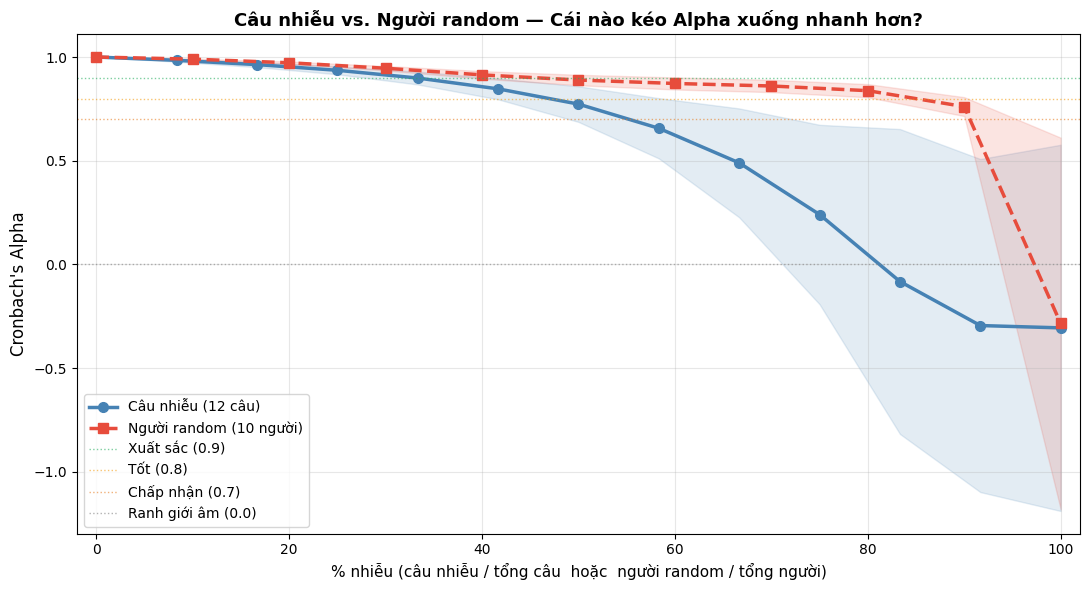

Điểm alpha rớt dưới 0.7:
  Câu nhiễu : từ 58% nhiễu trở đi (alpha = 0.6564)
  Người random: từ 100% nhiễu trở đi (alpha = -0.2848)


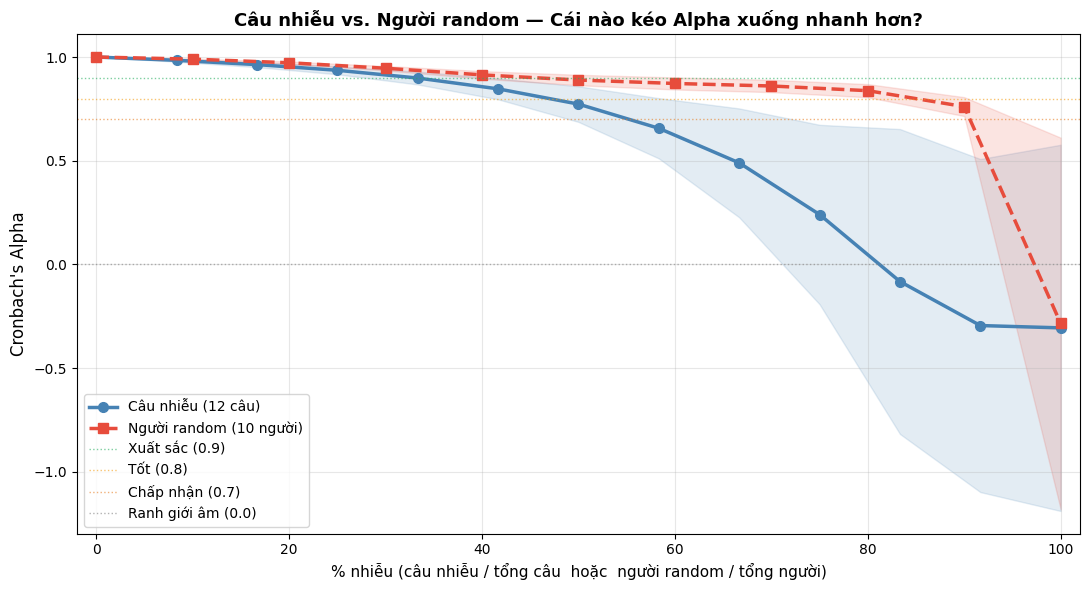

Điểm alpha rớt dưới 0.7:
  Câu nhiễu : từ 58% nhiễu trở đi (alpha = 0.6564)
  Người random: từ 100% nhiễu trở đi (alpha = -0.2848)


In [109]:
N_TRIALS_C = 2000

# --- Câu nhiễu (đã có sẵn từ noisy_results) ---
# Dùng lại noisy_results, convert sang % nhiễu
pct_noisy   = [n / N_Q * 100        for n, _, _ in noisy_results]
means_noisy = [m                    for _, m, _ in noisy_results]
stds_noisy  = [s                    for _, _, s in noisy_results]

# --- Người random (đã có sẵn từ people_results) ---
pct_people   = [n / N_PEOPLE * 100  for n, _, _ in people_results]
means_people = [m                   for _, m, _ in people_results]
stds_people  = [s                   for _, _, s in people_results]

# --- Vẽ ---
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(pct_noisy, means_noisy, 'o-', color='steelblue', lw=2.5, ms=7,
        label='Câu nhiễu (12 câu)')
ax.fill_between(pct_noisy,
                [m-s for m,s in zip(means_noisy, stds_noisy)],
                [m+s for m,s in zip(means_noisy, stds_noisy)],
                alpha=0.15, color='steelblue')

ax.plot(pct_people, means_people, 's--', color='#e74c3c', lw=2.5, ms=7,
        label='Người random (10 người)')
ax.fill_between(pct_people,
                [m-s for m,s in zip(means_people, stds_people)],
                [m+s for m,s in zip(means_people, stds_people)],
                alpha=0.15, color='#e74c3c')

for val, lbl, color in [(0.9,'Xuất sắc','#27ae60'), (0.8,'Tốt','#f39c12'),
                         (0.7,'Chấp nhận','#e67e22'), (0.0,'Ranh giới âm','gray')]:
    ax.axhline(val, color=color, lw=1, ls=':', alpha=0.6, label=f'{lbl} ({val})')

ax.set_xlabel('% nhiễu (câu nhiễu / tổng câu  hoặc  người random / tổng người)', fontsize=11)
ax.set_ylabel("Cronbach's Alpha", fontsize=12)
ax.set_title("Câu nhiễu vs. Người random — Cái nào kéo Alpha xuống nhanh hơn?",
             fontsize=13, fontweight='bold')
ax.set_xlim(-2, 102)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Tìm điểm gãy (alpha < 0.7) ---
print('Điểm alpha rớt dưới 0.7:')
for label, pcts, means in [('Câu nhiễu ', pct_noisy,  means_noisy),
                             ('Người random', pct_people, means_people)]:
    for pct, m in zip(pcts, means):
        if m < 0.7:
            print(f'  {label}: từ {pct:.0f}% nhiễu trở đi (alpha = {m:.4f})')
            break
